In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
df = pd.read_csv('insurance.csv')
# df.head()
df.isnull().sum()
# df.info()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: >

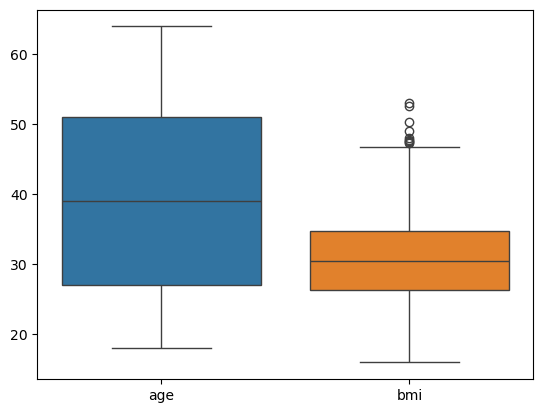

In [37]:
sns.boxplot(df[['age','bmi']])

<Axes: ylabel='children'>

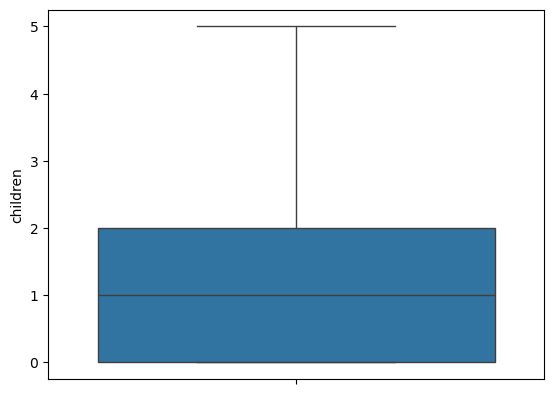

In [38]:
sns.boxplot(df['children'])

<Axes: ylabel='charges'>

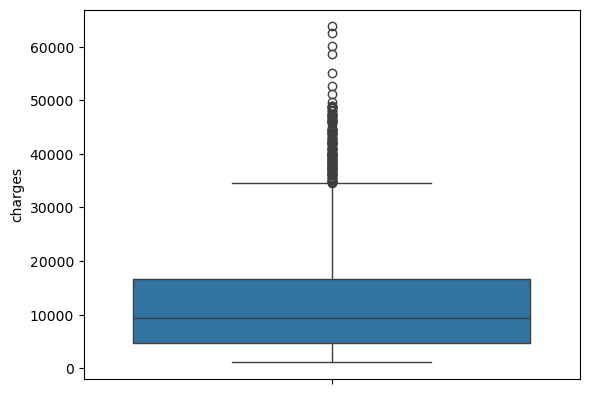

In [39]:
sns.boxplot(df['charges'])

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [41]:
feature=['age','bmi','children']
target=['charges']
X=df[feature]
Y=df[target]

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

## Linear Regression

In [43]:
linear_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('linear_reg',LinearRegression())
])
linear_reg.fit(X_train, Y_train)
linear_reg_pred = linear_reg.predict(X_test)

Text(0, 0.5, 'Predicted charges')

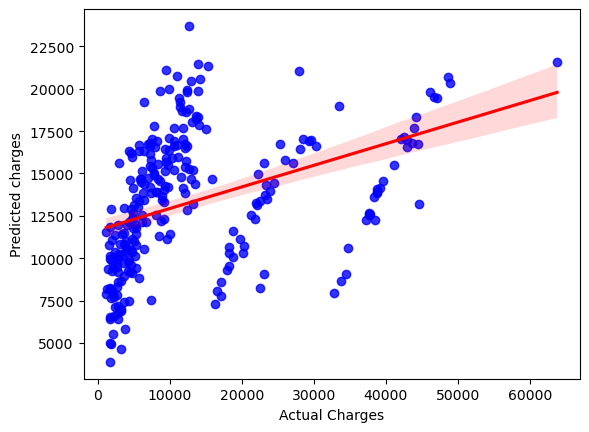

In [44]:
sns.regplot(x=Y_test, y=linear_reg_pred, color='blue', line_kws={'color':'red'})
plt.xlabel('Actual Charges')
plt.ylabel('Predicted charges')

In [45]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_score = cross_val_score(
    linear_reg,
    X,
    Y.values.ravel(),
    cv=kfold,
    scoring='r2'
)

print(f'Cross validation score: {cv_score}')
print(f'Average cross validation score: {cv_score.mean()}')

Cross validation score: [0.15489592 0.09234254 0.13529968 0.02546071 0.13330527]
Average cross validation score: 0.1082608254878725


In [46]:
def adjustR2(r2, n, p):
    return 1-((1-r2)*(n-1))/(n-p-1)

n_sample = X_test.shape[0]
p = X_train.shape[1]

In [47]:
mae = mean_absolute_error(Y_test, linear_reg_pred)
mse = mean_squared_error(Y_test, linear_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, linear_reg_pred)
linreg_adjust_r2 = adjustR2(r2, n_sample, p)

print(f'Mean Absolute Error(MAE): {mae}')
print(f'Mean Squared Error(MSE): {mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function): {rmse}')
print(f'R2 Score (Residual Score / Cost Function): {r2}')
print(f'Adjusted R2 Score: {linreg_adjust_r2}')

Mean Absolute Error(MAE): 9181.311632897381
Mean Squared Error(MSE): 131201335.64669803
Root Mean Squared Error(RMSE/Loss Function): 11454.315153980095
R2 Score (Residual Score / Cost Function): 0.15489592484270776
Adjusted R2 Score: 0.14529246944319307


## Polynomial Regression

In [48]:
poly_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('poly_reg', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_reg',LinearRegression())
])
poly_reg.fit(X_train, Y_train)
poly_reg_pred = poly_reg.predict(X_test)

poly_mae = mean_absolute_error(Y_test, poly_reg_pred)
poly_mse = mean_squared_error(Y_test, poly_reg_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(Y_test, poly_reg_pred)
poly_reg_adjust_r2 = adjustR2(poly_r2, n_sample, p)

print(f'Mean Absolute Error(MAE): {poly_mae}')
print(f'Mean Squared Error(MSE): {poly_mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function): {poly_rmse}')
print(f'R2 Score (Residual Score / Cost Function): {poly_r2}')
print(f'Adjusted R2 Score: {poly_reg_adjust_r2}')

Mean Absolute Error(MAE): 9165.733208715
Mean Squared Error(MSE): 132880932.17923523
Root Mean Squared Error(RMSE/Loss Function): 11527.399194060872
R2 Score (Residual Score / Cost Function): 0.14407717923108132
Adjusted R2 Score: 0.13435078354052543


## Ridge Regression

In [49]:
ridge_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('ridge_reg', Ridge(alpha = 1.0)),
])
ridge_reg.fit(X_train, Y_train)
ridge_reg_pred = ridge_reg.predict(X_test)

ridge_r2 = r2_score(Y_test, ridge_reg_pred)
print(f'R2 Score (Residual Score / Cost Function): {ridge_r2}')


R2 Score (Residual Score / Cost Function): 0.15484693092016488


## Lasso Regression

In [50]:
lasso_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('lasso_reg', Lasso(alpha = 0.1)),
])
lasso_reg.fit(X_train, Y_train)
lasso_reg_pred = lasso_reg.predict(X_test)

lasso_r2 = r2_score(Y_test, lasso_reg_pred)
print(f'R2 Score (Residual Score / Cost Function): {lasso_r2}')


R2 Score (Residual Score / Cost Function): 0.1548944270100734


## ElasticNet Regression

In [51]:
en_reg = Pipeline([
    ('scaler',StandardScaler()),
    ('en_reg', ElasticNet(alpha = 0.1)),
])
en_reg.fit(X_train, Y_train)
en_reg_pred = en_reg.predict(X_test)

en_r2 = r2_score(Y_test, en_reg_pred)
print(f'R2 Score (Residual Score / Cost Function): {en_r2}')


R2 Score (Residual Score / Cost Function): 0.15221157989615108


In [54]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_poly',PolynomialFeatures(degree=2, include_bias=False)),
    ('rf_regressor', RandomForestRegressor())
])
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(Y_test,rf_pred)
rf_mse = mean_squared_error(Y_test,rf_pred)
rf_rmse = np.sqrt(rf_mse)
r2 = r2_score(Y_test,rf_pred)

print(f'Mean Absolute Error(MAE):{rf_mae}')
print(f'Mean Squared Error(MSE):{rf_mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function):{rf_rmse}')
print(f'R2 Score(Residual Score/ Cost Function):{r2}')

c:\Users\Acer\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Absolute Error(MAE):9643.77302849231
Mean Squared Error(MSE):166665163.0518242
Root Mean Squared Error(RMSE/Loss Function):12909.886252474273
R2 Score(Residual Score/ Cost Function):-0.07353639189416272


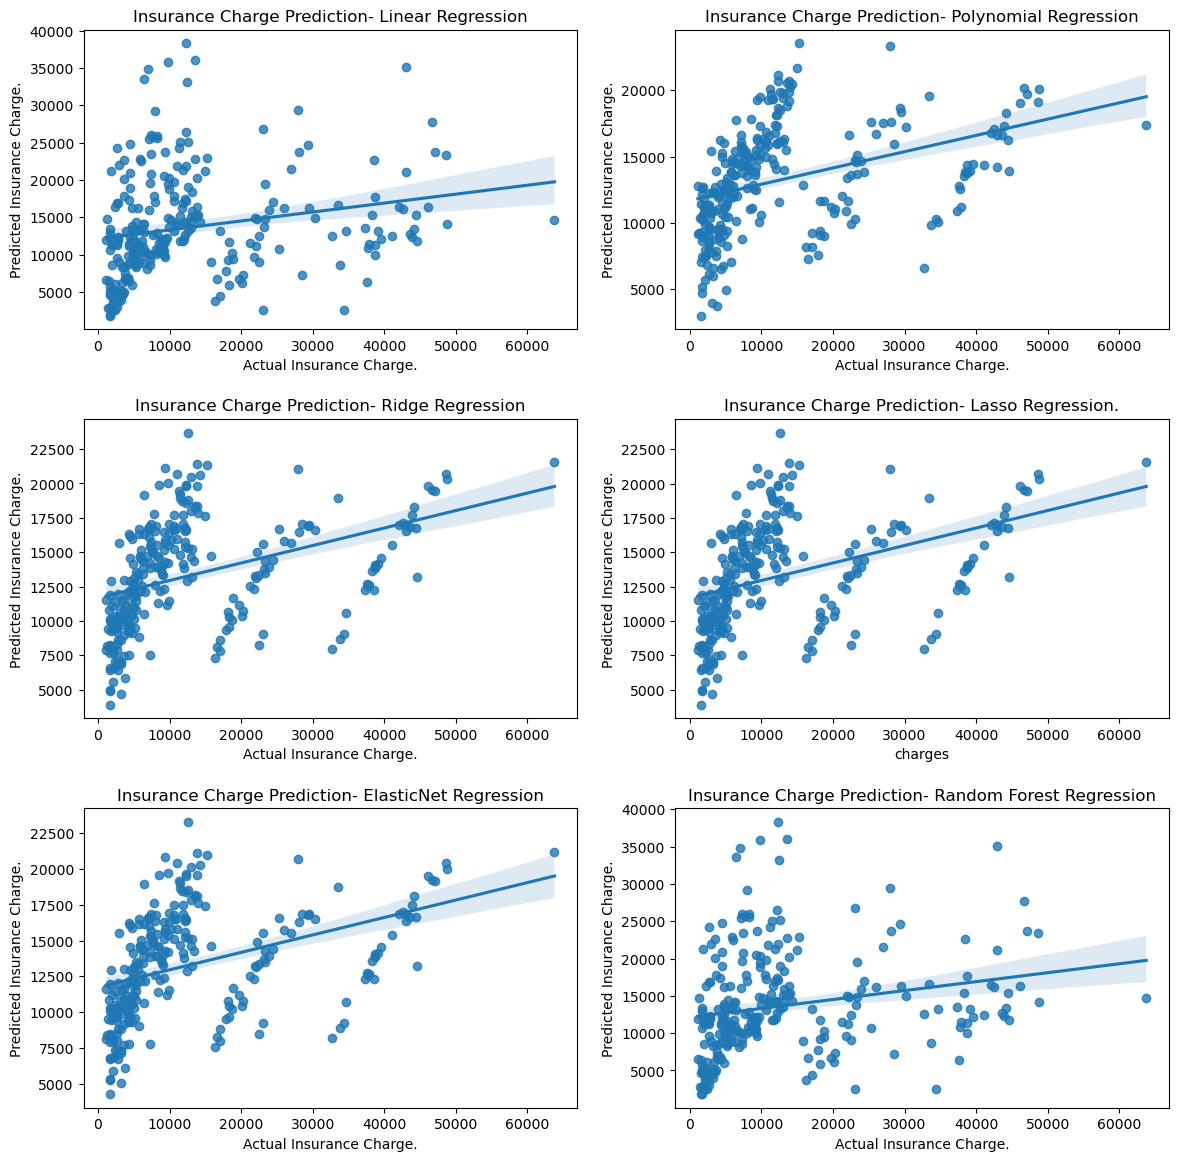

In [55]:
fig, axes = plt.subplots(3,2,figsize =(14,14))
plt.subplots_adjust(hspace=0.3)

sns.regplot(x=Y_test, y=rf_pred, ax=axes[0,0])
axes[0,0].set_title('Insurance Charge Prediction- Linear Regression')
axes[0,0].set_xlabel('Actual Insurance Charge.')
axes[0,0].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=poly_reg_pred, ax=axes[0,1])
axes[0,1].set_title(('Insurance Charge Prediction- Polynomial Regression'))
axes[0,1].set_xlabel('Actual Insurance Charge.')
axes[0,1].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=ridge_reg_pred, ax=axes[1,0])
axes[1,0].set_title(('Insurance Charge Prediction- Ridge Regression'))
axes[1,0].set_xlabel('Actual Insurance Charge.')
axes[1,0].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=lasso_reg_pred, ax=axes[1,1])
axes[1,1].set_title('Insurance Charge Prediction- Lasso Regression.')
axes[1,1].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=en_reg_pred, ax=axes[2,0])
axes[2,0].set_title(('Insurance Charge Prediction- ElasticNet Regression'))
axes[2,0].set_xlabel('Actual Insurance Charge.')
axes[2,0].set_ylabel('Predicted Insurance Charge.')

sns.regplot(x=Y_test, y=rf_pred, ax=axes[2,1])
axes[2,1].set_title(('Insurance Charge Prediction- Random Forest Regression'))
axes[2,1].set_xlabel('Actual Insurance Charge.')
axes[2,1].set_ylabel('Predicted Insurance Charge.')


plt.show()